# 데이터분석

In [1]:
!pwd

/home/jovyan/work


In [5]:
# https://data.seoul.go.kr/dataList/10956/S/2/datasetView.do#
import pandas as pd
file_path = './dataset/청소년정신건강20260604.csv'
df = pd.read_csv(file_path)
df

,시점,스트레스 인지율,스트레스 인지율.1,스트레스 인지율.2,우울감 경험률,우울감 경험률.1,우울감 경험률.2,자살 생각률,자살 생각률.1,자살 생각률.2
0,시점,전체,남학생,여학생,전체,남학생,여학생,전체,남학생,여학생
1,2025,42.6,34.0,51.8,26.8,23.5,30.3,12.7,9.4,16.2


In [6]:
new_name = ['시점','스트레스','스트레스남학생','스트레스여학생','우울감경험율','우울남학생','우울여학생','자살생각률','자살남학생','자살여학생']
df.columns = new_name
df

,시점,스트레스,스트레스남학생,스트레스여학생,우울감경험율,우울남학생,우울여학생,자살생각률,자살남학생,자살여학생
0,시점,전체,남학생,여학생,전체,남학생,여학생,전체,남학생,여학생
1,2025,42.6,34.0,51.8,26.8,23.5,30.3,12.7,9.4,16.2


In [7]:
ori = df.iloc[1:,1:]
ori

,스트레스,스트레스남학생,스트레스여학생,우울감경험율,우울남학생,우울여학생,자살생각률,자살남학생,자살여학생
1,42.6,34.0,51.8,26.8,23.5,30.3,12.7,9.4,16.2


In [8]:
# 2번 인덱스를 생성, 토탈 100에서 값을 뺀 값
ori.loc[2] = 100 - ori.loc[1,:].astype('float')
ori

,스트레스,스트레스남학생,스트레스여학생,우울감경험율,우울남학생,우울여학생,자살생각률,자살남학생,자살여학생
1,42.6,34.0,51.8,26.8,23.5,30.3,12.7,9.4,16.2
2,57.4,66.0,48.2,73.2,76.5,69.7,87.3,90.6,83.8


In [9]:
ori['응답'] = ['그렇다', '아니다']
ori

,스트레스,스트레스남학생,스트레스여학생,우울감경험율,우울남학생,우울여학생,자살생각률,자살남학생,자살여학생,응답
1,42.6,34.0,51.8,26.8,23.5,30.3,12.7,9.4,16.2,그렇다
2,57.4,66.0,48.2,73.2,76.5,69.7,87.3,90.6,83.8,아니다


In [12]:
data = ori.set_index('응답')
data

,스트레스,스트레스남학생,스트레스여학생,우울감경험율,우울남학생,우울여학생,자살생각률,자살남학생,자살여학생
응답,,,,,,,,,
그렇다,42.6,34.0,51.8,26.8,23.5,30.3,12.7,9.4,16.2
아니다,57.4,66.0,48.2,73.2,76.5,69.7,87.3,90.6,83.8


Text(0.2, 0.4, '한글')

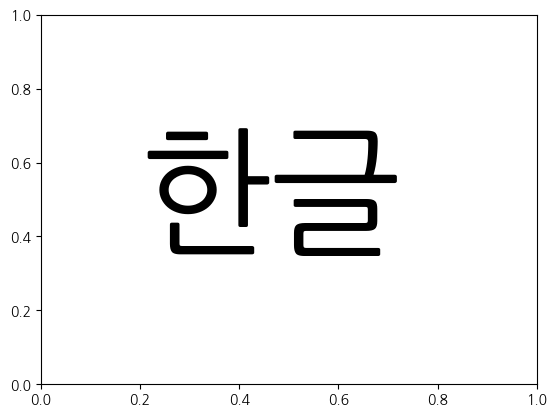

In [13]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [14]:
# 데이터 타입변경
data['스트레스'] = data['스트레스'].astype('float')

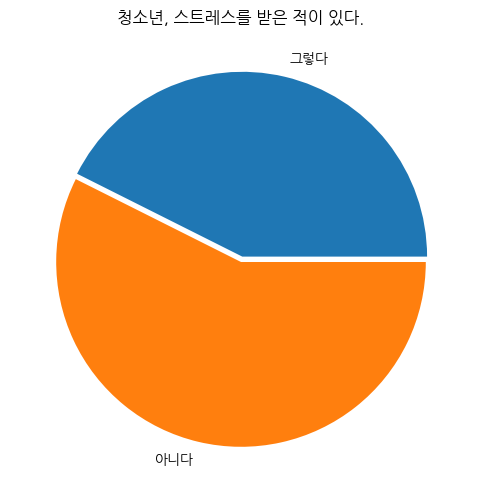

In [18]:
# data['스트레스'].plot.pie()
plt.figure(figsize=(6,6))
plt.pie(data['스트레스'], labels=data.index, explode=[0.03,0])
plt.title('청소년, 스트레스를 받은 적이 있다.')
plt.show()

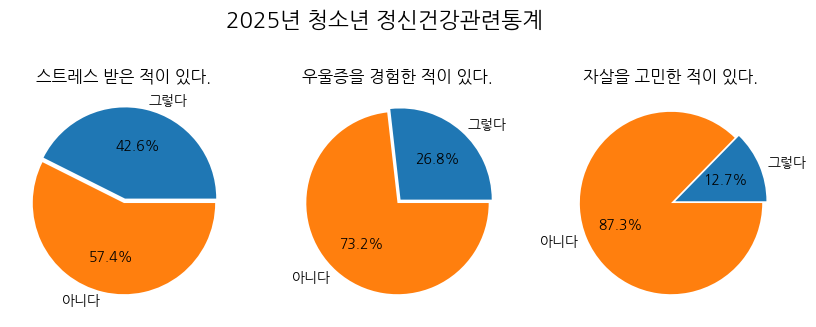

In [29]:
# 경험
fig, ax = plt.subplots(1,3, figsize=(10,4))
# data['스트레스'].astype('float').plot.pie(ax=ax[0],autopct="%.1f%%", explode=[0.03,0])
# data['우울감경험율'].astype('float').plot.pie(ax=ax[1],autopct="%.1f%%", explode=[0.03,0])
# data['자살생각률'].astype('float').plot.pie(ax=ax[2],autopct="%.1f%%", explode=[0.03,0])

# 권장
ax[0].pie(data['스트레스'], labels=data.index, autopct="%.1f%%", explode=[0.05,0])
ax[0].set_title('스트레스 받은 적이 있다.')
ax[1].pie(data['우울감경험율'], labels=data.index, autopct="%.1f%%", explode=[0.05,0])
ax[1].set_title('우울증을 경험한 적이 있다.')
ax[2].pie(data['자살생각률'], labels=data.index, autopct="%.1f%%", explode=[0.05,0])
ax[2].set_title('자살을 고민한 적이 있다.')

plt.suptitle('2025년 청소년 정신건강관련통계', fontsize=16)

plt.show()

#### 2025년 청소년 정신건강 통계 분석
본 통계 자료는 2025년 청소년들이 겪고 있는 정신건강 문제를 스트레스, 우울증, 자살 고민 세 가지 측면에서 조사한 결과입니다.

1. 스트레스 인지율
- 질문: 스트레스 받은 적이 있다.
- 조사 결과: 청소년의 42.6%가 스트레스를 받은 적이 '그렇다'고 응답했습니다. 절반에 가까운 청소년들이 일상적인 스트레스에 노출되어 있음을 보여줍니다. ('아니다'는 57.4%)
- 주요 원인:
  - 학업 및 성적 압박: 경쟁적인 교육 환경 속에서 좋은 성적과 대학 진학에 대한 부담감이 가장 큰 원인으로 꼽힙니다.
  - 외모 및 신체적 변화: 급격한 신체 성장과 호르몬 변화 속에서 외모에 대한 콤플렉스나 타인의 시선에 민감하게 반응하게 됩니다.

3. 우울증 경험률
- 질문: 우울증을 경험한 적이 있다.
- 조사 결과: 청소년 4명 중 1명 꼴인 26.8%가 우울증을 경험한 적이 '그렇다'고 답했습니다. 청소년기 우울증 문제가 단순한 감정 기복을 넘어 적극적인 관심이 필요한 수준임을 시사합니다. ('아니다'는 73.2%)
- 주요 원인:
  - 대인관계 갈등: 또래 집단에서의 소외감(따돌림), 친구 관계의 갈등, 혹은 부모 및 교사와의 소통 부재와 불화가 우울감을 심화시킵니다.
  - SNS 과의존과 상대적 박탈감: 스마트폰과 SNS 사용이 일상화되면서, 화면 속 타인의 화려한 일상과 자신을 비교하며 느끼는 '비교 심리'와 박탈감이 우울증의 새로운 원인으로 대두되고 있습니다.

3. 자살 고민 경험률
- 질문: 자살을 고민한 적이 있다.
- 조사 결과: 조사 대상 청소년의 12.7%가 자살을 고민한 적이 '그렇다'고 응답했습니다. 비율 자체는 세 항목 중 가장 낮지만, 10%가 넘는 청소년이 극단적인 선택을 고민한 적이 있다는 점에서 매우 심각하게 받아들여야 할 지표입니다. ('아니다'는 87.3%)
- 주요 원인:
  - 스트레스와 우울증의 누적: 앞서 언급된 학업 압박, 가정 불화, 대인관계 스트레스가 적절히 해소되지 못하고 장기간 누적되면서 한계 상황에 다다를 때 발생합니다.

  - 미래에 대한 불안과 무기력감: 경제적 불황이나 취업난 등 사회적 분위기 속에서 "노력해도 바뀔 것이 없다"는 패배주의나 미래에 대한 극심한 불안감이 청소년들을 막막함으로 내몰고 있습니다.

<br />

#### 요약 및 시사점
상당수의 청소년들이 스트레스(42.6%)와 우울증(26.8%)을 겪고 있으며, 이는 자살 고민(12.7%)이라는 심각한 위기로 이어질 위험성을 내포하고 있습니다. 청소년들의 정신건강을 예방하고 치료하기 위한 사회적 차원의 조기 개입과 상담 시스템 확대가 시급함을 보여주는 통계입니다.